In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
data_path = os.path.join('..', 'data', 'raw', 'world_bank', 'data_world_bank.csv')
df_world_bank = pd.read_csv(data_path)

df_world_bank.head(100)

,Country,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate
0,Afghanistan,1980,NaN,9000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.258,13169311.0,15.680999
1,Afghanistan,1981,NaN,180000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.406,11937581.0,15.903758
2,Afghanistan,1982,NaN,100000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.058,10991378.0,16.107378
3,Afghanistan,1983,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.517,10917982.0,16.293666
4,Afghanistan,1984,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.473,11190221.0,16.464427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Angola,1985,NaN,278000000.0,7.554065e+09,3.499999,772.468833,NaN,NaN,NaN,0.0,42.495,9779120.0,30.916115
96,Angola,1986,NaN,234000000.0,7.072536e+09,2.900002,697.526602,NaN,NaN,NaN,0.0,42.739,10139450.0,32.321814
97,Angola,1987,NaN,119000000.0,8.084412e+09,4.082749,770.101140,NaN,NaN,NaN,0.0,40.786,10497858.0,33.727677
98,Angola,1988,NaN,131000000.0,8.769837e+09,6.128890,807.439628,NaN,NaN,NaN,0.0,41.471,10861291.0,35.126880


In [3]:
countries = df_world_bank['Country'].unique()
print(countries)
len(countries)

['Afghanistan' 'Algeria' 'Angola' 'Argentina' 'Australia' 'Austria'
 'Bangladesh' 'Belarus' 'Belgium' 'Bolivia' 'Brazil' 'Bulgaria' 'Cambodia'
 'Canada' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus'
 'Czech Republic' 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Estonia' 'Ethiopia' 'Finland' 'France' 'Germany' 'Ghana'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kuwait' 'Laos' 'Latvia' 'Lebanon' 'Lithuania' 'Luxembourg'
 'Malaysia' 'Malta' 'Mexico' 'Morocco' 'Myanmar' 'Nepal' 'Netherlands'
 'New Zealand' 'Nigeria' 'Norway' 'Oman' 'Pakistan' 'Panama' 'Paraguay'
 'Peru' 'Philippines' 'Poland' 'Portugal' 'Qatar' 'Romania'
 'Russian Federation' 'Saudi Arabia' 'Serbia' 'Singapore' 'Slovakia'
 'Slovenia' 'South Africa' 'Spain' 'Sri Lanka' 'Sweden' 'Switzerland'
 'Thailand' 'Tunisia' 'Turkey' 'Ukraine' 'United Arab Emirates'
 'United Kingdom' 'United St

96

In [4]:
df_world_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    4320 non-null   object 
 1   Year                       4320 non-null   int64  
 2   Exports                    3853 non-null   float64
 3   Foreign Direct Investment  4109 non-null   float64
 4   GDP                        4124 non-null   float64
 5   GDP Growth                 4113 non-null   float64
 6   GDP per Capita             4124 non-null   float64
 7   Government Spending        3784 non-null   float64
 8   Imports                    3853 non-null   float64
 9   Inflation Rate             3871 non-null   float64
 10  Investment                 3866 non-null   float64
 11  Life Expectancy            4320 non-null   float64
 12  Population                 4320 non-null   float64
 13  Unemployment Rate          4320 non-null   float

In [5]:
df_world_bank.describe()

,Year,Exports,Foreign Direct Investment,GDP,GDP Growth,GDP per Capita,Government Spending,Imports,Inflation Rate,Investment,Life Expectancy,Population,Unemployment Rate
count,4320.000000,3.853000e+03,4.109000e+03,4.124000e+03,4113.000000,4124.000000,3.784000e+03,3.853000e+03,3871.000000,3.866000e+03,4320.000000,4.320000e+03,4320.000000
mean,2002.000000,1.357686e+11,1.098049e+10,5.049187e+11,3.345805,14354.775252,8.812065e+10,1.331205e+11,29.087816,1.357688e+11,71.560441,5.886362e+07,63.378249
std,12.988677,3.098130e+11,4.099136e+10,1.780263e+12,5.478791,19309.753406,2.768290e+11,3.213077e+11,278.616333,5.106140e+11,8.089341,1.723311e+08,21.215465
min,1980.000000,6.932810e+05,-3.434028e+11,4.077963e+08,-64.047107,22.952133,4.180568e+07,1.849551e+06,-16.117326,-2.465806e+09,31.473000,2.281380e+05,10.374611
25%,1991.000000,8.863698e+09,1.510000e+08,2.310445e+10,1.438347,1801.276949,3.804368e+09,1.040158e+10,2.168416,5.959241e+09,67.833750,5.382337e+06,51.382936
50%,2002.000000,2.931290e+10,1.322701e+09,8.102807e+10,3.542110,5817.384659,1.293429e+10,3.017795e+10,4.669820,2.207895e+10,72.971366,1.467852e+07,67.323365
75%,2013.000000,1.124330e+11,6.268781e+09,2.978931e+11,5.692571,20049.258230,4.964076e+10,1.066987e+11,10.350619,7.658006e+10,77.165854,4.657239e+07,79.254480
max,2024.000000,3.753056e+12,7.338265e+11,2.875096e+13,82.809329,137781.681659,3.570077e+12,4.103100e+12,11749.639632,7.768897e+12,84.580488,1.450936e+09,100.000000


In [6]:
df_world_bank['GDP'].corr(df_world_bank['GDP per Capita'])

np.float64(0.26100191142366097)

`Related columns doesn't have a high correlation, So it is safe to keep`

In [7]:
df_world_bank.isna().sum()

Country                        0
Year                           0
Exports                      467
Foreign Direct Investment    211
GDP                          196
GDP Growth                   207
GDP per Capita               196
Government Spending          536
Imports                      467
Inflation Rate               449
Investment                   454
Life Expectancy                0
Population                     0
Unemployment Rate              0
dtype: int64

In [8]:
df_world_bank.sort_values(['Country', 'Year'], inplace=True)

In [9]:
# CRITICAL: We split strictly by year to prevent future information (like 2020 COVID data)
# from leaking backward into the training set calculations.
train_end_year = 2015
df_train = df_world_bank[df_world_bank["Year"] <= train_end_year].copy()
df_test = df_world_bank[df_world_bank["Year"] > train_end_year].copy()
numeric_cols = df_world_bank.select_dtypes(include=["number"]).columns.tolist()
if "Year" in numeric_cols:
    numeric_cols.remove("Year")
for col in numeric_cols:
    df_train[col] = df_train.groupby("Country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="forward")
    )
    df_test[col] = df_test.groupby("Country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="forward")
    )
df_train.dropna(subset=numeric_cols, inplace=True)
df_test.dropna(subset=numeric_cols, inplace=True)
print("Train set missing values:\n", df_train.isna().sum().sum(), "total NaNs")
print("Test set missing values:\n", df_test.isna().sum().sum(), "total NaNs")


Train set missing values:
 0 total NaNs
Test set missing values:
 0 total NaNs


In [10]:
def apply_hampel_filter(series, window_size=5, n_sigmas=3):
    """
    Applies a backward-looking Hampel Filter to identify and replace extreme local outliers.
    
    The filter uses a rolling Median and Median Absolute Deviation (MAD) to detect 
    anomalies. Values exceeding `n_sigmas` * MAD are replaced with the local median.
    """
    # 1. Rolling Median (backward-looking to prevent leakage)
    rolling_median = series.rolling(window=window_size, min_periods=1).median()
    
    # 2. Rolling Median Absolute Deviation (MAD)
    def mad_func(x):
        return np.median(np.abs(x - np.median(x)))
    
    rolling_mad = series.rolling(window=window_size, min_periods=1).apply(mad_func, raw=True)
    
    # 3. Identify Outliers (threshold = n_sigmas * 1.4826 * MAD)
    threshold = n_sigmas * 1.4826 * rolling_mad
    outliers = np.abs(series - rolling_median) > threshold
    
    # 4. Replace only the outliers with the rolling median
    series_cleaned = series.copy()
    # Ensure we don't try to replace if all values were NaN or no outliers
    if outliers.any():
        series_cleaned[outliers] = rolling_median[outliers]
    
    return series_cleaned
for col in numeric_cols:
    df_train[col] = df_train.groupby('Country')[col].transform(lambda x: apply_hampel_filter(x, window_size=5))
    df_test[col] = df_test.groupby('Country')[col].transform(lambda x: apply_hampel_filter(x, window_size=5))


In [11]:
log_cols = [c for c in numeric_cols if c not in ['Country', 'Year']]

for col in log_cols:
    df_train[col] = np.sign(df_train[col]) * np.log1p(np.abs(df_train[col]))
    df_test[col]  = np.sign(df_test[col])  * np.log1p(np.abs(df_test[col]))


In [12]:
from sklearn.preprocessing import RobustScaler

scale_cols = [c for c in df_train.columns if c not in ['Country', 'Year']]

scaler = RobustScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols]  = scaler.transform(df_test[scale_cols])


In [13]:
global_train = df_train.groupby('Year')[['GDP Growth', 'Inflation Rate']].mean().reset_index()
global_train.rename(columns={'GDP Growth': 'Global_Avg_GDP_Growth', 'Inflation Rate': 'Global_Avg_Inflation'}, inplace=True)
df_train = df_train.merge(global_train, on='Year', how='left')

global_test = df_test.groupby('Year')[['GDP Growth', 'Inflation Rate']].mean().reset_index()
global_test.rename(columns={'GDP Growth': 'Global_Avg_GDP_Growth', 'Inflation Rate': 'Global_Avg_Inflation'}, inplace=True)
df_test = df_test.merge(global_test, on='Year', how='left')


In [14]:
crisis_years = [
    1980, 1981, 1982,  # Early 1980s Global Recession
    1990, 1991,        # Early 1990s Recession
    1997, 1998,        # Asian Financial Crisis
    2001,              # Dot-com Bubble Burst & 9/11 Shock
    2008, 2009,        # Great Financial Crisis
    2020               # COVID-19 Global Recession
]

df_train['Is_Crisis_Year'] = df_train['Year'].isin(crisis_years).astype(int)
df_test['Is_Crisis_Year']  = df_test['Year'].isin(crisis_years).astype(int)


In [16]:
# Temporarily concatenate to safely calculate rolling windows across the 2015 split boundary
df_full = pd.concat([df_train, df_test]).sort_values(['Country', 'Year'])
# 1. Volatility (Standard Deviation of the last 5 years, shifted by 1 to prevent current-year leakage)
df_full['Inflation_volatility'] = df_full.groupby('Country')['Inflation Rate'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
)
df_full['GDP_volatility'] = df_full.groupby('Country')['GDP Growth'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).std()
)
# 2. Inflation Shock (1 if current inflation > 5-year mean + 2*std)
def detect_shock(x):
    """
    Returns 1 if the current value exceeds the 5-year rolling mean + 2 standard deviations.
    Acts as an explicit binary trigger for structural economic shocks.
    """
    mean = x.rolling(5, min_periods=1).mean()
    std = x.rolling(5, min_periods=1).std()
    return (x > mean + 2 * std).astype(int)
df_full['Inflation_shock'] = df_full.groupby('Country')['Inflation Rate'].transform(detect_shock)
# Split back into train and test
df_train = df_full[df_full['Year'] <= 2015].copy()
df_test  = df_full[df_full['Year'] > 2015].copy()
# The first year of any country will have a NaN volatility (std of 1 item is NaN). We safely fill this with 0.
df_train.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)


In [17]:
from sklearn.feature_selection import VarianceThreshold

ignore_cols = ['Country', 'Year', 'GDP']
features = [c for c in df_train.columns if c not in ignore_cols]

selector = VarianceThreshold(threshold=0.1)
selector.fit(df_train[features])

low_var_cols = [c for i, c in enumerate(features) if not selector.get_support()[i]]

if low_var_cols:
    df_train.drop(columns=low_var_cols, inplace=True)
    df_test.drop(columns=low_var_cols, inplace=True)

print(f"Dropped low-variance features: {low_var_cols}")
print(f"Remaining features: {len(df_train.columns)}")


Dropped low-variance features: ['Inflation_volatility', 'Inflation_shock']
Remaining features: 18


In [ ]:
import networkx as nx
from sklearn.decomposition import PCA
import numpy as np
features = [c for c in df_train.columns if c not in ignore_cols]
corr_matrix = df_train[features].corr().abs()
# Build a graph to find clusters of highly correlated features
edges = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            edges.append((corr_matrix.columns[i], corr_matrix.columns[j]))
G = nx.Graph()
G.add_nodes_from(features)
G.add_edges_from(edges)
# Extract clusters (connected components with >1 feature)
clusters = [list(c) for c in nx.connected_components(G) if len(c) > 1]
for idx, cluster in enumerate(clusters):
    print(f"Applying PCA to highly correlated cluster: {cluster}")
    # Compress the cluster's shared variance into a single Principal Component
    pca = PCA(n_components=1)
    
    train_pca = pca.fit_transform(df_train[cluster])
    test_pca  = pca.transform(df_test[cluster])
    
    pc_name = f'PCA_Cluster_{idx}'
    df_train[pc_name] = train_pca
    df_test[pc_name]  = test_pca
    
    # Drop the original redundant columns
    df_train.drop(columns=cluster, inplace=True)
    df_test.drop(columns=cluster, inplace=True)
print(f"\nFeatures remaining after PCA compression: {len(df_train.columns)}")


Applying PCA to highly correlated cluster: ['Imports', 'Government Spending', 'Investment', 'Exports']

Features remaining after PCA compression: 15


In [ ]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

features = [c for c in df_train.columns if c not in ignore_cols]
target = 'GDP'

# Initialize XGBoost as the estimator for the wrapper method
estimator = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)

# RFE: We let it select the top 10 most powerful features recursively
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)

rfe.fit(df_train[features], df_train[target])

selected_features = [f for i, f in enumerate(features) if rfe.support_[i]]
dropped_features = [f for i, f in enumerate(features) if not rfe.support_[i]]

# Keep only the optimal wrapper-selected features, plus our ignored columns
cols_to_keep = ignore_cols + selected_features
df_train = df_train[cols_to_keep]
df_test  = df_test[cols_to_keep]

print(f"\nRFE Dropped Features: {dropped_features}")
print(f"\nRFE Selected Optimal Features: {selected_features}")


Running RFE Wrapper Method... (this may take a few seconds)

RFE Dropped Features: ['Global_Avg_GDP_Growth', 'Is_Crisis_Year']

RFE Selected Optimal Features: ['Foreign Direct Investment', 'GDP Growth', 'GDP per Capita', 'Inflation Rate', 'Life Expectancy', 'Population', 'Unemployment Rate', 'Global_Avg_Inflation', 'GDP_volatility', 'PCA_Cluster_0']

Final Train shape: (2799, 13)
Final Test shape:  (831, 13)


### Step 15 — Pipeline Visualizations
The following plots visually verify the transformations and selections made by our pipeline.

#### 15.1 Outlier Handling (Hampel Filter)
Demonstrating how the Hampel filter isolates extreme spikes without shifting the baseline trend.

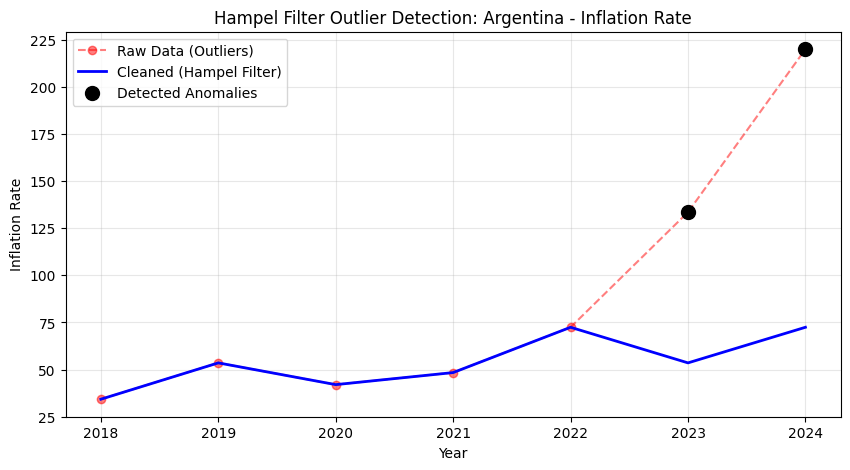

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# We use a slice of the raw dataframe (before it was cleaned) for demonstration
country = 'Argentina'
metric = 'Inflation Rate'
df_demo = df_world_bank[df_world_bank['Country'] == country].copy().sort_values('Year')

series = df_demo[metric]
rolling_median = series.rolling(5, min_periods=1).median()
rolling_mad = series.rolling(5, min_periods=1).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
outliers = np.abs(series - rolling_median) > (3 * 1.4826 * rolling_mad)
cleaned_series = series.copy()
cleaned_series[outliers] = rolling_median[outliers]

plt.figure(figsize=(10, 5))
plt.plot(df_demo['Year'], series, color='red', label='Raw Data (Outliers)', linestyle='--', marker='o', alpha=0.5)
plt.plot(df_demo['Year'], cleaned_series, color='blue', label='Cleaned (Hampel Filter)', linewidth=2)
plt.scatter(df_demo['Year'][outliers], series[outliers], color='black', s=100, zorder=5, label='Detected Anomalies')
plt.title(f'Hampel Filter Outlier Detection: {country} - {metric}')
plt.xlabel('Year')
plt.ylabel(metric)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### 15.2 Multicollinearity Network
Visualizing the network of highly correlated features (> 0.85) that we compressed using PCA.

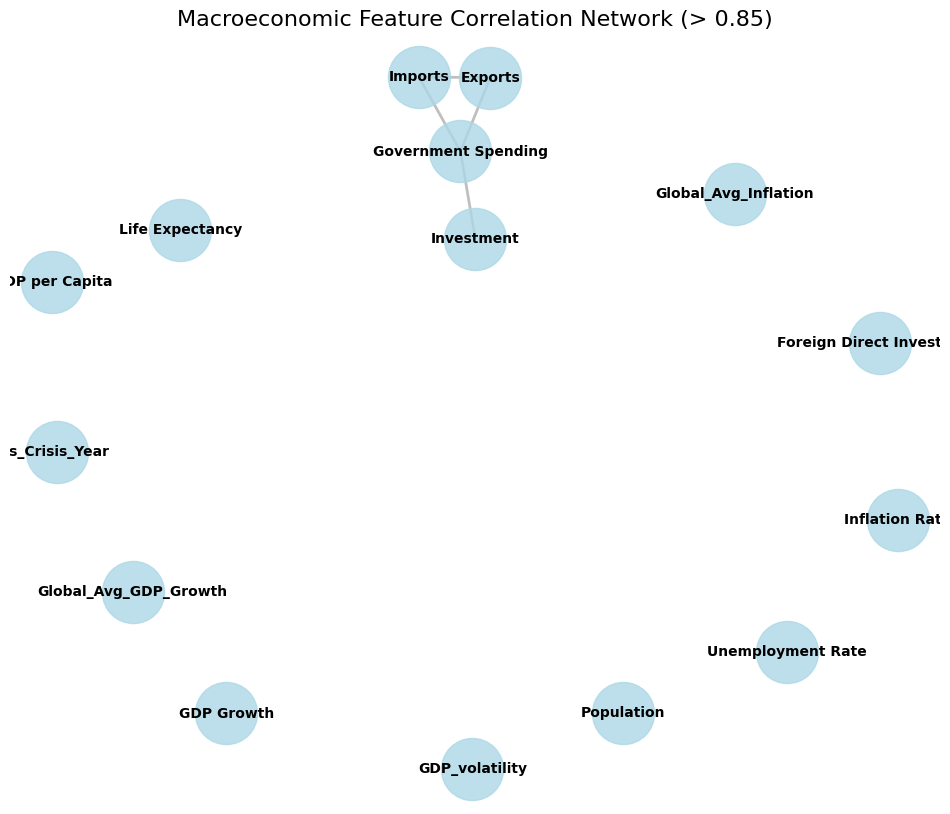

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Macroeconomic Feature Correlation Network (> 0.85)', fontsize=16)
plt.axis('off')
plt.show()


#### 15.3 Feature Importance (RFE Wrapper)
Displaying the predictive power of the final selected features according to the XGBoost wrapper.

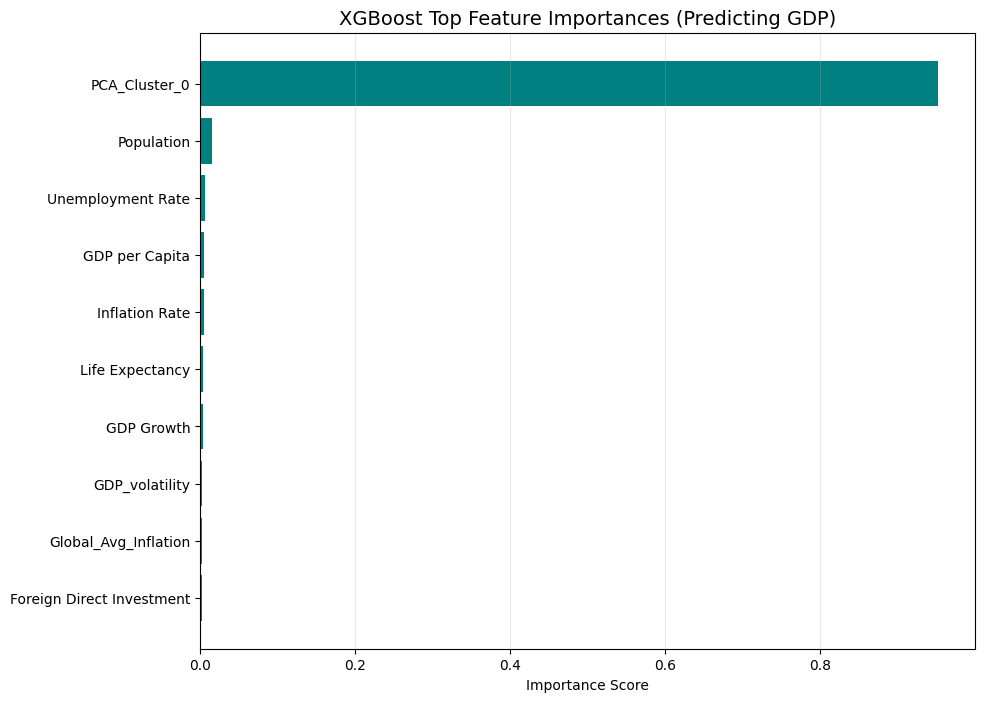

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# rfe.estimator_ holds the model fitted on the *selected* features
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rfe.estimator_.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(importance['Feature'], importance['Importance'], color='teal')
plt.title('XGBoost Top Feature Importances (Predicting GDP)', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()


In [ ]:
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import numpy as np



class Handling():
    def __init__(self):
        self.le = LabelEncoder()

    def handle_country(self, train_, test_):
        train_ = train_.copy()
        test_  = test_.copy()

        train_['country_id'] = self.le.fit_transform(train_['Country'])
        test_['country_id']  = self.le.transform(test_['Country'])

        train_ = train_.drop(columns=['Country'])
        test_  = test_.drop(columns=['Country'])

        num_countries = len(self.le.classes_)

        return train_, test_, num_countries

    @staticmethod
    def prepare_multi_output_ds_panel(df, feature_cols, target_cols, window_size=5, batch_size=32):
        X_country = []
        X_ts      = []
        y_target  = []

        print(f"Preparing panel data with {len(df['country_id'].unique())} countries...")

        for country_id, group in df.groupby('country_id', sort=True):
            group    = group.sort_values('Year').reset_index(drop=True)
            n_periods = len(group)

            if n_periods < window_size:
                print(f"  Warning: Country {country_id} has {n_periods} periods < window_size={window_size}, skipping")
                continue

            ts_data     = group[feature_cols].values.astype('float32')
            target_data = group[target_cols].values.astype('float32').flatten()
            n_windows   = n_periods - window_size

            for i in range(n_windows):
                X_country.append(country_id)
                X_ts.append(ts_data[i:i+window_size])
                y_target.append(target_data[i+window_size])

            print(f"  Country {country_id}: {n_windows} windows created")

        X_country = np.array(X_country, dtype=np.int32)
        X_ts      = np.array(X_ts,      dtype=np.float32)
        y_target  = np.array(y_target,  dtype=np.float32)

        print(f"\nTotal windows : {len(X_country)}")
        print(f"X_ts shape    : {X_ts.shape}")
        print(f"y_target shape: {y_target.shape}\n")

        ds = tf.data.Dataset.from_tensor_slices((X_country, X_ts, y_target))

        def map_fn(country, ts, target):
            return {"country_in": country, "ts_in": ts}, target

        ds = ds.map(map_fn)
        return ds.shuffle(min(1000, len(X_country))).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    def predict_by_country(self, model, df_full, country_name, feature_cols, target_col, window_size=5):
        if country_name not in self.le.classes_:
            print(f"Country '{country_name}' not found. Available countries:")
            print(list(self.le.classes_))
            return None

        country_id = self.le.transform([country_name])[0]
        country_df = df_full[df_full['country_id'] == country_id].sort_values('Year')

        if len(country_df) < window_size:
            print(f"Not enough data for '{country_name}'. Required: {window_size}, available: {len(country_df)}")
            return None

        last_window   = country_df[feature_cols].values[-window_size:].astype('float32')
        ts_input      = last_window[np.newaxis, :, :]
        country_input = np.array([[country_id]], dtype=np.int32)

        prediction      = model.predict({"country_in": country_input, "ts_in": ts_input}, verbose=0)
        predicted_value = prediction[0][0]
        last_year       = country_df['Year'].max()

        print(f"\nCountry         : {country_name}")
        print(f"Last year in data: {int(last_year)}")
        print(f"Predicted GDP    : {predicted_value:.4f}")

        return predicted_value


class R2ScoreExact(tf.keras.metrics.Metric):
    def __init__(self, name='r2_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
        self.sum_y  = self.add_weight(name='sum_y',  initializer='zeros')
        self.sum_y2 = self.add_weight(name='sum_y2', initializer='zeros')
        self.count  = self.add_weight(name='count',  initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y2.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        mean_y = self.sum_y / (self.count + tf.keras.backend.epsilon())
        ss_tot = self.sum_y2 - self.count * tf.square(mean_y)
        return 1.0 - self.ss_res / (ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for w in [self.ss_res, self.sum_y, self.sum_y2, self.count]:
            w.assign(0.)


class Modeling():
    @staticmethod
    def build_multi_target_lstm(num_countries, num_features, num_targets, window_size=5):
        country_in = layers.Input(shape=(1,), name="country_in", dtype=tf.int32)
        emb        = layers.Embedding(num_countries, 8)(country_in)
        emb        = layers.Reshape((8,))(emb)
        emb_seq    = layers.RepeatVector(window_size)(emb)

        ts_in  = layers.Input(shape=(window_size, num_features), name="ts_in")
        merged = layers.Concatenate()([ts_in, emb_seq])

        x = layers.LSTM(64, return_sequences=True, dropout=0.2)(merged)
        x = layers.LSTM(32, dropout=0.2)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.Dropout(0.2)(x)

        output = layers.Dense(num_targets, name="output")(x)
        model  = Model(inputs=[country_in, ts_in], outputs=output)

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='mse',
            metrics=['mae', R2ScoreExact()]
        )

        return model




  

In [ ]:

train_, test_ = df_train, df_test

print("=" * 60)
print("DATA PREPARATION")
print("=" * 60)
print(f"Train shape: {train_.shape}")
print(f"Test shape : {test_.shape}")
print(f"\nData types:\n{train_.dtypes}\n")

H = Handling()
train_, test_, num_countries = H.handle_country(train_, test_)

train_full = train_.copy()
test_full  = test_.copy()

print(f"Number of countries: {num_countries}")

train_ = train_.sort_values(['country_id', 'Year'])
test_  = test_.sort_values(['country_id', 'Year'])

target_col = "GDP"

selected_features = [c for c in train_.columns
                        if c not in (target_col, 'country_id', 'Year')]

print(f"Selected features ({len(selected_features)}): {selected_features}")

window = 5

print("\n" + "=" * 60)
print("PREPARING DATASETS")
print("=" * 60)

train_ds = H.prepare_multi_output_ds_panel(train_, selected_features, target_col, window)
test_ds  = H.prepare_multi_output_ds_panel(test_,  selected_features, target_col, window)

print("\n" + "=" * 60)
print("VERIFYING DATA SHAPES")
print("=" * 60)

for batch_x, batch_y in train_ds.take(1):
    print(f"Country input: {batch_x['country_in'].shape}")
    print(f"TS input     : {batch_x['ts_in'].shape}")
    print(f"Target shape : {batch_y.shape}")

print("\n" + "=" * 60)
print("BUILDING MODEL")
print("=" * 60)

md    = Modeling()
model = md.build_multi_target_lstm(
    num_countries=num_countries,
    num_features=len(selected_features),
    num_targets=1,
    window_size=window
)
print(model.summary())

model.fit(
    train_ds,
    epochs=50,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

print("\n" + "=" * 60)
print("TEST EVALUATION")
print("=" * 60)

test_loss, test_mae, test_r2 = model.evaluate(test_ds, verbose=0)
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test MAE       : {test_mae:.6f}")
print(f"Test R2        : {test_r2:.6f}")

print("\n" + "=" * 60)
print("COUNTRY PREDICTION")
print("=" * 60)

country_name = input("Enter country name: ").strip()

H.predict_by_country(
    model        = model,
    df_full      = test_full,
    country_name = country_name,
    feature_cols = selected_features,
    target_col   = target_col,
    window_size  = window
)